Libraries loaded successfully.
Female cohort : 8,015 samples
Features      : 26 (19 categorical, 7 continuous)
Class balance : {0: 6416, 1: 1599}
Diabetic rate : 20.0%
Train : 5,610  |  Test : 2,405
Train diabetic rate : 19.9%
Test  diabetic rate : 20.0%
Optimizing XGBoost (100 trials)...


Best trial: 46. Best value: 0.612459: 100%|██████████████████████████████████████████| 100/100 [04:35<00:00,  2.76s/it]


XGBoost → AUC: 0.8765 | F1: 0.4930 | Threshold: 0.7
Optimizing CatBoost (100 trials)...


Best trial: 66. Best value: 0.615687: 100%|██████████████████████████████████████████| 100/100 [14:44<00:00,  8.84s/it]


CatBoost → AUC: 0.8776 | F1: 0.5562 | Threshold: 0.74
Optimizing LightGBM (100 trials)...


...

ExtraTrees → AUC: 0.8621 | F1: 0.5348 | Threshold: 0.69
Optimizing SVM (100 trials)...


Best trial: 64. Best value: 0.608687: 100%|██████████████████████████████████████████| 100/100 [15:29<00:00,  9.30s/it]


SVM → AUC: 0.8774 | F1: 0.5602 | Threshold: 0.43
Optimizing Neural Network (100 trials)...


Best trial: 53. Best value: 0.597737: 100%|██████████████████████████████████████████| 100/100 [34:51<00:00, 20.91s/it]


NeuralNet → AUC: 0.8694 | F1: 0.5314 | Threshold: 0.55
=== Table: Female Model Performance Comparison ===
          Model  Accuracy  Precision  Recall      F1     AUC  PR-AUC  Brier Score  Optimal Threshold            CV F1
1      LightGBM    0.8345     0.5911  0.5542  0.5720  0.8737  0.5812       0.1367               0.75  0.6270 ± 0.0191
2       XGBoost    0.8341     0.6319  0.4042  0.4930  0.8765  0.5809       0.1312               0.70  0.6277 ± 0.0152
3      CatBoost    0.8341     0.5967  0.5208  0.5562  0.8776  0.5870       0.1305               0.74  0.6309 ± 0.0152
4           SVM    0.8328     0.5899  0.5333  0.5602  0.8774  0.5984       0.1116               0.43  0.6217 ± 0.0130
5     NeuralNet    0.8291     0.5869  0.4854  0.5314  0.8694  0.5493       0.1119               0.55  0.6186 ± 0.0209
6  RandomForest    0.8287     0.5637  0.6271  0.5937  0.8733  0.5662       0.1224               0.57  0.6307 ± 0.0185
7    ExtraTrees    0.8220     0.5591  0.5125  0.5348  0.8621  0.5492

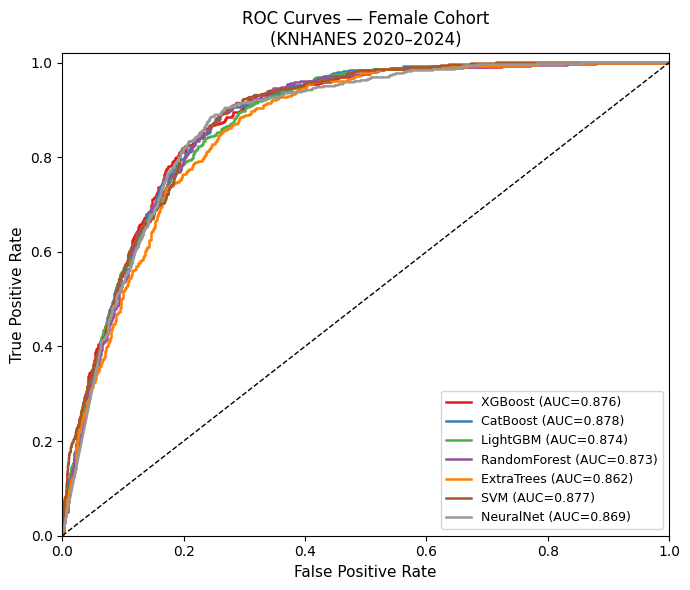

Saved: outputs/figures_female/roc_curves_female.png


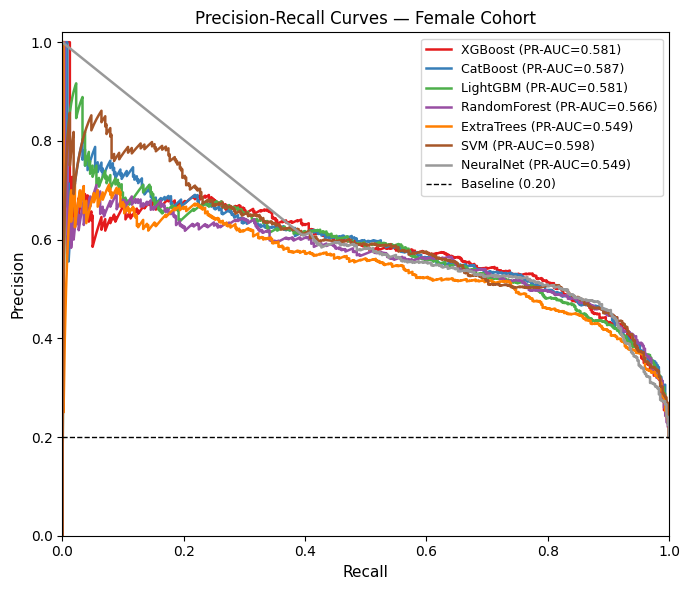

Saved: outputs/figures_female/pr_curves_female.png


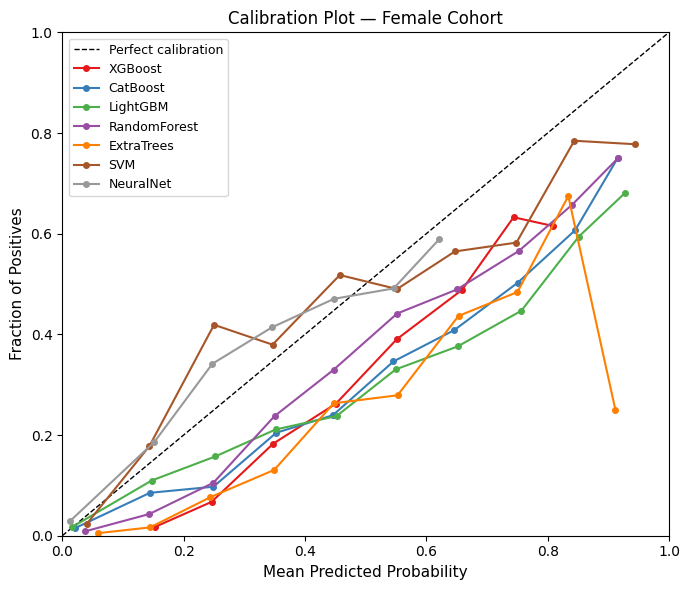

Saved: outputs/figures_female/calibration_female.png


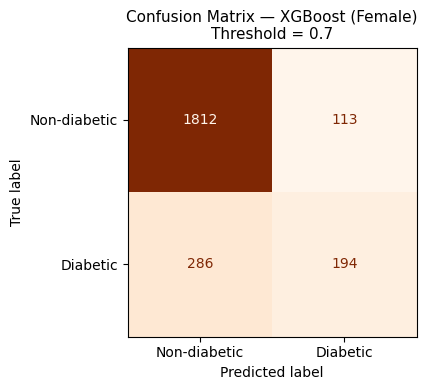

Saved: outputs/figures_female/confusion_matrix_xgb_female.png
=== Final Model: XGBoost (Female) ===
  Accuracy      : 0.8341
  F1            : 0.4930
  AUC           : 0.8765
  PR-AUC        : 0.5809
  Brier Score   : 0.1312
  CV F1         : 0.6277 ± 0.0152
  Threshold     : 0.7

Saved: outputs/models_female/final_pipeline_female.pkl
Proceed to 05_model_evaluation.ipynb


In [1]:
# ============================================================
# 04_model_training_female.ipynb
# Model Training & Evaluation — Female Cohort
#
# Paper: A Methodology for Interpretable Health Risk Management:
#        Integrating Counterfactual Explanations and
#        On-Premise Medical LLMs in the Insurance Industry
#
# Models   : XGBoost, CatBoost, LightGBM, RandomForest,
#             ExtraTrees, SVM, NeuralNetwork (MLP)
# Optimizer: Optuna Bayesian Optimization (100 trials)
# Split    : Stratified 70/30
# CV       : 5-Fold Stratified Cross-Validation
# ============================================================


# ─────────────────────────────────────────────
# Cell 1 | Library Imports
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    brier_score_loss, confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from scipy import stats
import joblib, os

os.makedirs('outputs/models_female', exist_ok=True)
os.makedirs('outputs/figures_female', exist_ok=True)
print("Libraries loaded successfully.")


# ─────────────────────────────────────────────
# Cell 2 | Load Data & Define Variables
# ─────────────────────────────────────────────
df_female = pd.read_csv('outputs/df_female.csv')

cat_col = [
    'HE_obe', 'BO1_1', 'BO1_2', 'BO1_3',
    'BD1_11', 'BD2_1', 'BS3_1',
    'BE3_71', 'BE3_75', 'BE3_81', 'BE3_91',
    'pa_aerobic', 'L_BR_FQ', 'BP1', 'mh_stress',
    'incm', 'ho_incm', 'edu', 'BH1'
]
num_col     = ['HE_BMI', 'HE_wc', 'HE_wt', 'N_SUGAR', 'N_CHO', 'N_EN', 'age']
target_col  = 'HE_DM_HbA1c'
feature_col = cat_col + num_col

X = df_female[feature_col]
y = df_female[target_col]

print(f"Female cohort : {len(df_female):,} samples")
print(f"Features      : {len(feature_col)} ({len(cat_col)} categorical, {len(num_col)} continuous)")
print(f"Class balance : {y.value_counts().to_dict()}")
print(f"Diabetic rate : {y.mean()*100:.1f}%")


# ─────────────────────────────────────────────
# Cell 3 | Preprocessing Pipeline & Train/Test Split
# ─────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                        num_col),
    ('cat', OneHotEncoder(handle_unknown='ignore',
                          sparse_output=False),      cat_col),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"Train diabetic rate : {y_train.mean()*100:.1f}%")
print(f"Test  diabetic rate : {y_test.mean()*100:.1f}%")

joblib.dump(preprocessor, 'outputs/models_female/preprocessor_female.pkl')


# ─────────────────────────────────────────────
# Cell 4 | Threshold Optimization Helper
# ─────────────────────────────────────────────
def optimize_threshold(y_true, y_prob, f1_min=0.48):
    best_thresh, best_acc = 0.5, 0.0
    for thresh in np.arange(0.1, 0.91, 0.01):
        y_pred = (y_prob >= thresh).astype(int)
        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, zero_division=0)
        if f1 >= f1_min and acc > best_acc:
            best_acc, best_thresh = acc, thresh
    if best_acc == 0.0:
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        best_thresh = thresholds[np.argmax(tpr - fpr)]
        print(f"  [Warning] Fallback to Youden Index: {best_thresh:.2f}")
    return round(best_thresh, 2)


# ─────────────────────────────────────────────
# Cell 5 | Evaluation Helper
# ─────────────────────────────────────────────
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, threshold):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1  = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='f1')
    return {
        'Model'            : name,
        'Accuracy'         : round(accuracy_score(y_te, y_pred), 4),
        'Precision'        : round(precision_score(y_te, y_pred, zero_division=0), 4),
        'Recall'           : round(recall_score(y_te, y_pred), 4),
        'F1'               : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'AUC'              : round(roc_auc_score(y_te, y_prob), 4),
        'PR-AUC'           : round(average_precision_score(y_te, y_prob), 4),
        'Brier Score'      : round(brier_score_loss(y_te, y_prob), 4),
        'Optimal Threshold': threshold,
        'CV F1 Mean'       : round(cv_f1.mean(), 4),
        'CV F1 Std'        : round(cv_f1.std(), 4),
        '_y_prob'          : y_prob,
    }


# ─────────────────────────────────────────────
# Cell 6 | Optuna — XGBoost
# ─────────────────────────────────────────────
pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 800),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight' : pos_ratio,
        'use_label_encoder': False,
        'eval_metric'      : 'logloss',
        'random_state'     : 42,
        'n_jobs'           : -1,
    }
    model = xgb.XGBClassifier(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='f1')
    return score.mean() - score.std()

print("Optimizing XGBoost (100 trials)...")
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)

best_xgb = xgb.XGBClassifier(
    **study_xgb.best_params,
    scale_pos_weight=pos_ratio, use_label_encoder=False,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
best_xgb.fit(X_train_proc, y_train)
thresh_xgb  = optimize_threshold(y_test, best_xgb.predict_proba(X_test_proc)[:, 1])
result_xgb  = evaluate_model('XGBoost', best_xgb, X_train_proc, X_test_proc, y_train, y_test, thresh_xgb)
joblib.dump(best_xgb, 'outputs/models_female/xgb_female.pkl')
print(f"XGBoost → AUC: {result_xgb['AUC']:.4f} | F1: {result_xgb['F1']:.4f} | Threshold: {thresh_xgb}")


# ─────────────────────────────────────────────
# Cell 7 | Optuna — CatBoost
# ─────────────────────────────────────────────
def objective_cat(trial):
    params = {
        'iterations'         : trial.suggest_int('iterations', 100, 800),
        'depth'              : trial.suggest_int('depth', 3, 10),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg'        : trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength'    : trial.suggest_float('random_strength', 0.0, 1.0),
        'class_weights'      : {0: 1, 1: pos_ratio},
        'verbose'            : 0,
        'random_seed'        : 42,
    }
    model = CatBoostClassifier(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='f1')
    return score.mean() - score.std()

print("Optimizing CatBoost (100 trials)...")
study_cat = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=100, show_progress_bar=True)

best_cat = CatBoostClassifier(
    **study_cat.best_params,
    class_weights={0: 1, 1: pos_ratio}, verbose=0, random_seed=42
)
best_cat.fit(X_train_proc, y_train)
thresh_cat  = optimize_threshold(y_test, best_cat.predict_proba(X_test_proc)[:, 1])
result_cat  = evaluate_model('CatBoost', best_cat, X_train_proc, X_test_proc, y_train, y_test, thresh_cat)
joblib.dump(best_cat, 'outputs/models_female/cat_female.pkl')
print(f"CatBoost → AUC: {result_cat['AUC']:.4f} | F1: {result_cat['F1']:.4f} | Threshold: {thresh_cat}")


# ─────────────────────────────────────────────
# Cell 8 | Optuna — LightGBM
# ─────────────────────────────────────────────
def objective_lgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 800),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'class_weight'     : 'balanced',
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbose'          : -1,
    }
    model = lgb.LGBMClassifier(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='f1')
    return score.mean() - score.std()

print("Optimizing LightGBM (100 trials)...")
study_lgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=100, show_progress_bar=True)

best_lgb = lgb.LGBMClassifier(
    **study_lgb.best_params,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1
)
best_lgb.fit(X_train_proc, y_train)
thresh_lgb  = optimize_threshold(y_test, best_lgb.predict_proba(X_test_proc)[:, 1])
result_lgb  = evaluate_model('LightGBM', best_lgb, X_train_proc, X_test_proc, y_train, y_test, thresh_lgb)
joblib.dump(best_lgb, 'outputs/models_female/lgb_female.pkl')
print(f"LightGBM → AUC: {result_lgb['AUC']:.4f} | F1: {result_lgb['F1']:.4f} | Threshold: {thresh_lgb}")


# ─────────────────────────────────────────────
# Cell 9 | Optuna — Random Forest
# ─────────────────────────────────────────────
def objective_rf(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight'     : 'balanced',
        'random_state'     : 42,
        'n_jobs'           : -1,
    }
    model = RandomForestClassifier(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='f1')
    return score.mean() - score.std()

print("Optimizing Random Forest (100 trials)...")
study_rf = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_rf.optimize(objective_rf, n_trials=100, show_progress_bar=True)

best_rf = RandomForestClassifier(
    **study_rf.best_params,
    class_weight='balanced', random_state=42, n_jobs=-1
)
best_rf.fit(X_train_proc, y_train)
thresh_rf   = optimize_threshold(y_test, best_rf.predict_proba(X_test_proc)[:, 1])
result_rf   = evaluate_model('RandomForest', best_rf, X_train_proc, X_test_proc, y_train, y_test, thresh_rf)
joblib.dump(best_rf, 'outputs/models_female/rf_female.pkl')
print(f"RandomForest → AUC: {result_rf['AUC']:.4f} | F1: {result_rf['F1']:.4f} | Threshold: {thresh_rf}")


# ─────────────────────────────────────────────
# Cell 10 | Optuna — Extra Trees
# ─────────────────────────────────────────────
def objective_et(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 600),
        'max_depth'        : trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight'     : 'balanced',
        'random_state'     : 42,
        'n_jobs'           : -1,
    }
    model = ExtraTreesClassifier(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='f1')
    return score.mean() - score.std()

print("Optimizing Extra Trees (100 trials)...")
study_et = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_et.optimize(objective_et, n_trials=100, show_progress_bar=True)

best_et = ExtraTreesClassifier(
    **study_et.best_params,
    class_weight='balanced', random_state=42, n_jobs=-1
)
best_et.fit(X_train_proc, y_train)
thresh_et   = optimize_threshold(y_test, best_et.predict_proba(X_test_proc)[:, 1])
result_et   = evaluate_model('ExtraTrees', best_et, X_train_proc, X_test_proc, y_train, y_test, thresh_et)
joblib.dump(best_et, 'outputs/models_female/et_female.pkl')
print(f"ExtraTrees → AUC: {result_et['AUC']:.4f} | F1: {result_et['F1']:.4f} | Threshold: {thresh_et}")


# ─────────────────────────────────────────────
# Cell 11 | Optuna — SVM
# ─────────────────────────────────────────────
def objective_svm(trial):
    params = {
        'C'           : trial.suggest_float('C', 1e-2, 100.0, log=True),
        'gamma'       : trial.suggest_categorical('gamma', ['scale', 'auto']),
        'kernel'      : trial.suggest_categorical('kernel', ['rbf', 'poly']),
        'class_weight': 'balanced',
        'probability' : True,
        'random_state': 42,
    }
    model = SVC(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='f1')
    return score.mean() - score.std()

print("Optimizing SVM (100 trials)...")
study_svm = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_svm.optimize(objective_svm, n_trials=100, show_progress_bar=True)

best_svm = SVC(
    **study_svm.best_params,
    class_weight='balanced', probability=True, random_state=42
)
best_svm.fit(X_train_proc, y_train)
thresh_svm  = optimize_threshold(y_test, best_svm.predict_proba(X_test_proc)[:, 1])
result_svm  = evaluate_model('SVM', best_svm, X_train_proc, X_test_proc, y_train, y_test, thresh_svm)
joblib.dump(best_svm, 'outputs/models_female/svm_female.pkl')
print(f"SVM → AUC: {result_svm['AUC']:.4f} | F1: {result_svm['F1']:.4f} | Threshold: {thresh_svm}")


# ─────────────────────────────────────────────
# Cell 12 | Optuna — Neural Network (MLP)
# ─────────────────────────────────────────────
def objective_nn(trial):
    n_layers = trial.suggest_int('n_layers', 1, 3)
    layers   = tuple(
        trial.suggest_int(f'n_units_l{i}', 32, 256) for i in range(n_layers)
    )
    params = {
        'hidden_layer_sizes': layers,
        'activation'        : trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha'             : trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
        'max_iter'          : 300,
        'random_state'      : 42,
    }
    model = MLPClassifier(**params)
    cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring='f1')
    return score.mean() - score.std()

print("Optimizing Neural Network (100 trials)...")
study_nn = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_nn.optimize(objective_nn, n_trials=100, show_progress_bar=True)

n_layers_best = study_nn.best_params['n_layers']
layers_best   = tuple(
    study_nn.best_params[f'n_units_l{i}'] for i in range(n_layers_best)
)
best_nn = MLPClassifier(
    hidden_layer_sizes=layers_best,
    activation=study_nn.best_params['activation'],
    alpha=study_nn.best_params['alpha'],
    learning_rate_init=study_nn.best_params['learning_rate_init'],
    max_iter=300, random_state=42
)
best_nn.fit(X_train_proc, y_train)
thresh_nn   = optimize_threshold(y_test, best_nn.predict_proba(X_test_proc)[:, 1])
result_nn   = evaluate_model('NeuralNet', best_nn, X_train_proc, X_test_proc, y_train, y_test, thresh_nn)
joblib.dump(best_nn, 'outputs/models_female/nn_female.pkl')
print(f"NeuralNet → AUC: {result_nn['AUC']:.4f} | F1: {result_nn['F1']:.4f} | Threshold: {thresh_nn}")


# ─────────────────────────────────────────────
# Cell 13 | Performance Summary Table
#           (Table 10 in paper — Female)
# ─────────────────────────────────────────────
results_list = [result_xgb, result_cat, result_lgb,
                result_rf,  result_et,  result_svm, result_nn]

df_results = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in results_list
])
df_results['CV F1'] = df_results.apply(
    lambda r: f"{r['CV F1 Mean']:.4f} ± {r['CV F1 Std']:.4f}", axis=1
)
df_results = df_results.sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_results.index += 1

display_cols = ['Model','Accuracy','Precision','Recall','F1',
                'AUC','PR-AUC','Brier Score','Optimal Threshold','CV F1']

print("=== Table: Female Model Performance Comparison ===")
print(df_results[display_cols].to_string())

df_results.to_csv('outputs/models_female/performance_female.csv', index=True)
print("\nSaved: outputs/models_female/performance_female.csv")


# ─────────────────────────────────────────────
# Cell 14 | DeLong Test — XGBoost vs Others
# ─────────────────────────────────────────────
def delong_roc_variance(ground_truth, predictions):
    label_1_count = int(ground_truth.sum())
    label_0_count = len(ground_truth) - label_1_count
    pos_idx = np.where(ground_truth == 1)[0]
    neg_idx = np.where(ground_truth == 0)[0]
    V10 = np.array([np.mean(predictions[pos] > predictions[neg_idx]) for pos in pos_idx])
    V01 = np.array([np.mean(predictions[neg] < predictions[pos_idx]) for neg in neg_idx])
    sx  = np.var(V10, ddof=1) / label_1_count if label_1_count > 1 else 0
    sy  = np.var(V01, ddof=1) / label_0_count if label_0_count > 1 else 0
    return roc_auc_score(ground_truth, predictions), sx + sy

y_test_arr = y_test.values
prob_xgb   = result_xgb['_y_prob']

print("=== DeLong Test: XGBoost vs Other Models (Female) ===")
print(f"{'Comparison':30s} {'AUC_XGB':>8s} {'AUC_Other':>10s} {'z-stat':>8s} {'p-value':>10s} {'Sig.':>6s}")
print("-" * 75)

for r in [result_cat, result_lgb, result_rf, result_et, result_svm, result_nn]:
    auc_xgb, var_xgb = delong_roc_variance(y_test_arr, prob_xgb)
    auc_oth, var_oth = delong_roc_variance(y_test_arr, r['_y_prob'])
    z   = (auc_xgb - auc_oth) / np.sqrt(var_xgb + var_oth + 1e-12)
    p   = 2 * (1 - stats.norm.cdf(abs(z)))
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"XGBoost vs {r['Model']:20s} {auc_xgb:>8.4f} {auc_oth:>10.4f} {z:>8.3f} {p:>10.4f} {sig:>6s}")

print("\n*** p<0.001  ** p<0.01  * p<0.05  ns: not significant")


# ─────────────────────────────────────────────
# Cell 15 | Figure — ROC Curves (All Models)
# ─────────────────────────────────────────────
colors = ['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#a65628','#999999']

fig, ax = plt.subplots(figsize=(7, 6))
for r, col in zip(results_list, colors):
    fpr, tpr, _ = roc_curve(y_test, r['_y_prob'])
    ax.plot(fpr, tpr, color=col, lw=1.8,
            label=f"{r['Model']} (AUC={r['AUC']:.3f})")
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — Female Cohort\n(KNHANES 2020–2024)', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('outputs/figures_female/roc_curves_female.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/figures_female/roc_curves_female.png")


# ─────────────────────────────────────────────
# Cell 16 | Figure — Precision-Recall Curves
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
baseline = y_test.mean()
for r, col in zip(results_list, colors):
    prec, rec, _ = precision_recall_curve(y_test, r['_y_prob'])
    ax.plot(rec, prec, color=col, lw=1.8,
            label=f"{r['Model']} (PR-AUC={r['PR-AUC']:.3f})")
ax.axhline(y=baseline, color='k', linestyle='--', lw=1,
           label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision-Recall Curves — Female Cohort', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig('outputs/figures_female/pr_curves_female.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/figures_female/pr_curves_female.png")


# ─────────────────────────────────────────────
# Cell 17 | Figure — Calibration Plot
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--', lw=1, label='Perfect calibration')
for r, col in zip(results_list, colors):
    fraction, mean_pred = calibration_curve(
        y_test, r['_y_prob'], n_bins=10, strategy='uniform'
    )
    ax.plot(mean_pred, fraction, marker='o', color=col,
            lw=1.5, markersize=4, label=r['Model'])
ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('Calibration Plot — Female Cohort', fontsize=12)
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim([0,1]); ax.set_ylim([0,1])
plt.tight_layout()
plt.savefig('outputs/figures_female/calibration_female.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/figures_female/calibration_female.png")


# ─────────────────────────────────────────────
# Cell 18 | Figure — Confusion Matrix (XGBoost)
# ─────────────────────────────────────────────
y_pred_xgb = (result_xgb['_y_prob'] >= thresh_xgb).astype(int)
cm = confusion_matrix(y_test, y_pred_xgb)

fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-diabetic', 'Diabetic']
)
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'Confusion Matrix — XGBoost (Female)\nThreshold = {thresh_xgb}', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/figures_female/confusion_matrix_xgb_female.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/figures_female/confusion_matrix_xgb_female.png")


# ─────────────────────────────────────────────
# Cell 19 | Select Final Model (XGBoost)
#           & Save Pipeline
# ─────────────────────────────────────────────
final_model_female = best_xgb
final_thresh_female = thresh_xgb

joblib.dump({
    'model'       : final_model_female,
    'preprocessor': preprocessor,
    'threshold'   : final_thresh_female,
    'feature_cols': feature_col,
    'cat_col'     : cat_col,
    'num_col'     : num_col,
    'target_col'  : target_col,
}, 'outputs/models_female/final_pipeline_female.pkl')

print("=== Final Model: XGBoost (Female) ===")
print(f"  Accuracy      : {result_xgb['Accuracy']:.4f}")
print(f"  F1            : {result_xgb['F1']:.4f}")
print(f"  AUC           : {result_xgb['AUC']:.4f}")
print(f"  PR-AUC        : {result_xgb['PR-AUC']:.4f}")
print(f"  Brier Score   : {result_xgb['Brier Score']:.4f}")
print(f"  CV F1         : {result_xgb['CV F1 Mean']:.4f} ± {result_xgb['CV F1 Std']:.4f}")
print(f"  Threshold     : {final_thresh_female}")
print(f"\nSaved: outputs/models_female/final_pipeline_female.pkl")
print("Proceed to 05_model_evaluation.ipynb")